# Analise inicial do CSV 

## Importando bibliotecas

In [205]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#### Leitura otimizada do CSV completo

Como o arquivo CSV é muito grande, inicialmente eu tentei realizar a leitura usando chunks. Que ajudou na primeira inspeção dos dados, mas acabava sendo limitado, já que os resultados representavam apenas uma parte da base e não o ano inteiro.

Por isso, eu dei uma pesquisada em uma forma mais otimizada de carregar o CSV inteiro.

O `dtype` foi usado para definir manualmente o tipo de dado de algumas colunas durante o processo de leitura do arquivo. Fazendo isso eu evitei que o pandas escolhesse tipos mais pesados de forma automatica.


In [206]:
caminho_csv = Path("data/raw/viirs-snpp_2024_Brazil.csv")

df_original = pd.read_csv(
    caminho_csv,
    dtype={
        "latitude": "float32",
        "longitude": "float32",
        "bright_ti4": "float32",
        "scan": "float32",
        "track": "float32",
        "acq_time": "int16",
        "satellite": "category",
        "instrument": "category",
        "confidence": "category",
        "version": "category",
        "bright_ti5": "float32",
        "frp": "float32",
        "daynight": "category",
        "type": "int8"
    }
)

df = df_original.copy()

## Analisando quantas colunas o CSV tem 

In [207]:
df.shape

(1935740, 15)

#### Utilizando o método `.info()` para conseguir definir a tipagem das colunas (numéricas / categóricas). E tambem para descobrir a quantidade de valores nulos nos dados

In [208]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1935740 entries, 0 to 1935739
Data columns (total 15 columns):
 #   Column      Dtype   
---  ------      -----   
 0   latitude    float32 
 1   longitude   float32 
 2   bright_ti4  float32 
 3   scan        float32 
 4   track       float32 
 5   acq_date    str     
 6   acq_time    int16   
 7   satellite   category
 8   instrument  category
 9   confidence  category
 10  version     category
 11  bright_ti5  float32 
 12  frp         float32 
 13  daynight    category
 14  type        int8    
dtypes: category(5), float32(7), int16(1), int8(1), str(1)
memory usage: 81.2 MB


## Dicionário de dados

A base contém registros de focos de calor detectados por satélite no Brasil durante o ano de 2024. Cada linha representa um foco de calor identificado pelo sensor VIIRS.

| Coluna | O que representa | Tipo |
|---|---|---|
| `latitude` | Localização do foco de calor no sentido norte-sul. | Numérica |
| `longitude` | Localização do foco de calor no sentido leste-oeste. | Numérica |
| `bright_ti4` | Medida de temperatura/brilho do foco de calor. | Numérica |
| `scan` | Largura aproximada da área analisada pelo sensor. | Numérica |
| `track` | Comprimento aproximado da área analisada pelo sensor. | Numérica |
| `acq_date` | Data em que o foco de calor foi detectado. | Temporal |
| `acq_time` | Horário em que o foco foi detectado. | Temporal |
| `satellite` | Satélite que fez a detecção. | Categórica |
| `instrument` | Sensor usado para detectar o foco de calor. | Categórica |
| `confidence` | Nível de confiança da detecção. | Categórica |
| `version` | Versão dos dados utilizados. | Categórica |
| `bright_ti5` | Outra medida de temperatura/brilho captada pelo sensor. | Numérica |
| `frp` | Potência radiativa do fogo, usada como indicador de intensidade. | Numérica |
| `daynight` | Indica se a detecção ocorreu de dia ou de noite. | Categórica |
| `type` | Tipo do foco de calor registrado. | Categórica |

##### Ajustando notações científícas 

In [209]:
pd.set_option("display.float_format", "{:.2f}".format)

#### Utilizando o método `.describe()`  Para ter uma analise inicial em relação a: média, desvio padrão, valor mínimo e o valor maximo de cada coluna. Analisando esses dados eu consegui ter um norte maior sobre possiveis outliners 

## Dicionário do método `.describe()`

| Métrica | Significado |
|---|---|
| `count` | Quantidade de valores não nulos presentes na coluna. Ajuda a verificar se existem dados ausentes. |
| `mean` | Média dos valores da coluna. Representa o valor médio observado nos dados. |
| `std` | Desvio padrão. Mede o quanto os valores estão espalhados em relação à média. Quanto maior o desvio padrão, maior a variação dos dados. |
| `min` | Menor valor encontrado na coluna. Representa o limite inferior dos dados. |
| `25%` | Primeiro quartil, também chamado de Q1. Indica que 25% dos valores estão abaixo ou iguais a esse valor. |
| `50%` | Segundo quartil, também chamado de Q2 ou mediana. Indica o valor central da distribuição, onde 50% dos dados estão abaixo e 50% estão acima. |
| `75%` | Terceiro quartil, também chamado de Q3. Indica que 75% dos valores estão abaixo ou iguais a esse valor. |
| `max` | Maior valor encontrado na coluna. Representa o limite superior dos dados e pode ajudar a identificar possíveis valores extremos. |

In [210]:
df.describe()

,latitude,longitude,bright_ti4,scan,track,acq_time,bright_ti5,frp,type
count,1935740.00,1935740.00,1935740.00,1935740.00,1935740.00,1935740.00,1935740.00,1935740.00,1935740.00
mean,-10.22,-53.13,333.26,0.46,0.48,1205.30,299.14,12.29,0.02
std,6.07,7.03,18.93,0.09,0.11,599.08,10.05,25.17,0.23
min,-33.50,-73.66,208.00,0.32,0.36,244.00,195.49,-1.22,0.00
25%,-14.24,-57.58,315.71,0.39,0.38,504.00,292.74,2.34,0.00
50%,-9.22,-53.15,335.98,0.44,0.44,1625.00,297.43,5.35,0.00
75%,-6.58,-47.95,346.17,0.51,0.56,1713.00,305.05,11.56,0.00
max,5.16,-34.80,367.00,0.80,0.78,1916.00,386.64,1217.85,3.00


#### Análise inicial dos possíveis outliers

Bom, analisando o resultado do `.describe()`, eu percebi que a coluna que mais chamou atenção foi a `frp`. Olhando para os valores, dá para perceber que a maior parte dos dados da coluna está concentrada em valores bem menores, mas existe um valor máximo muito acima do resto. Onde 75% dos valores de `frp` estão abaixo de `8.75`, e o valor máximo é de `482.14`. Isso indica um sinal bem claro de outlier por conta dessa diferença gigantesca nos dados. Como o `frp` é o dado da intensidade do foco de calor, esse valor outlier representa um foco muito mais intenso do que os outros e isso pode ser um impecilio ao tentar prever alguma tendencia.

Inicialmente, eu também tinha achado muito esquisito o desvio padrão da coluna `acq_time`, porque conta do seu valor muito alto. Só que, analisando melhor, percebi que essa coluna representa horário no formato HHMM, e não uma variável numérica comum. Então essa variação no desvio padrão não é relevante para indicar outliers, talvez convertendo essa coluna, sera possivel estipular uma mediana e assim descobrir se possui alguum horario muito incomum.

outra coluna que talvez possua um outlier é a coluna `bright_ti4` que tem o seu valor minimo bem abaixo dos 25% no .describe()

### Analisando a quantidade de valores nulos.

In [211]:
df.isnull().sum()

latitude      0
longitude     0
bright_ti4    0
scan          0
track         0
acq_date      0
acq_time      0
satellite     0
instrument    0
confidence    0
version       0
bright_ti5    0
frp           0
daynight      0
type          0
dtype: int64

##### Bom, pelo visto não tem nunhum valor nulo nos df.

#### Analisando dados duplicados

In [212]:
df.duplicated().sum()

np.int64(0)

##### Os df não possui nenhuma duplicata

## Ajustando os dados

#### Separando as informações de data

Bom, nessa parte eu converti a coluna `acq_date` para o formato de data, para analisar `mes`, `dia` e `hora`.

In [213]:
df["acq_date"] = pd.to_datetime(df["acq_date"]) 

df["mes"] = df["acq_date"].dt.month
df["dia"] = df["acq_date"].dt.day
df["hora"] = df["acq_date"].dt.hour

df.head(2)

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type,mes,dia,hora
0,-2.27,-53.78,314.07,0.33,0.55,2024-01-01,425,N,VIIRS,n,2,271.41,0.63,N,0,1,1,0
1,-2.66,-54.27,328.12,0.35,0.57,2024-01-01,425,N,VIIRS,n,2,276.63,2.11,N,0,1,1,0


#### Analisando a mediana do período

Depois disso, eu tentei olhar a mediana dessas novas colunas para entender melhor em qual período os focos de calor estavam mais concentrados. Só que aqui deu para perceber um ponto importante: a coluna `hora` acabou sendo inútil, porque ela foi criada a partir de `acq_date`, e essa coluna só possui a data, sem o horário completo

In [214]:
mediana_periodo =(
df
[["dia", "mes", "hora"]].median()
)

mediana_periodo

dia    15.00
mes     9.00
hora    0.00
dtype: float64

#### Analisando a frequência por período

Como a mediana sozinha não mostrava tão bem a distribuição dos focos de calor, eu calculei a frequência percentual por mês e por dia.

In [215]:
frequencia_mes = (df["mes"].value_counts(normalize = True).sort_index() * 100)

frequencia_dia = (df["dia"].value_counts(normalize = True).sort_index() * 100) 

#### Distribuição de casos de focos de calor

Por fim, eu usei gráficos de barras para visualizar melhor quais meses os focos de calor aparecem com mais frequência, e tambem criei o gráfico por dia mostra como esses registros se distribuem ao longo dos dias do mês.

<Axes: title={'center': 'Percentual de focos de calor por mes '}, xlabel='mes'>

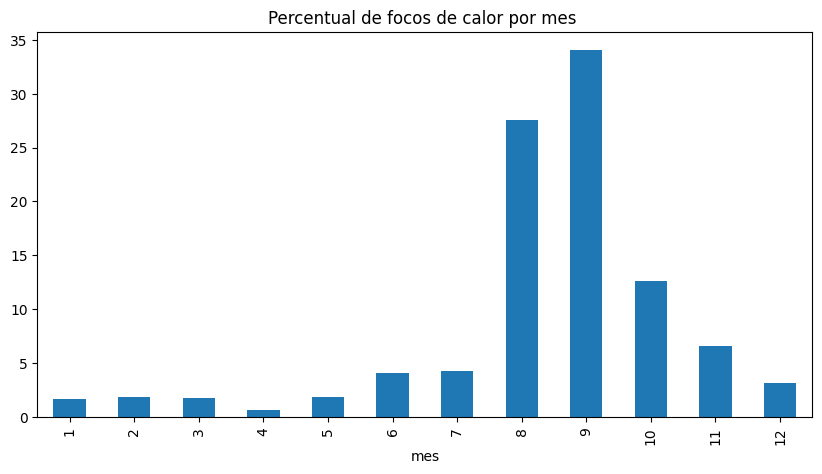

In [216]:
frequencia_mes.plot(kind = "bar", figsize = (10,5) , title = "Percentual de focos de calor por mes " )

<Axes: title={'center': 'Percentual de focos de calor por dia do mês'}, xlabel='dia'>

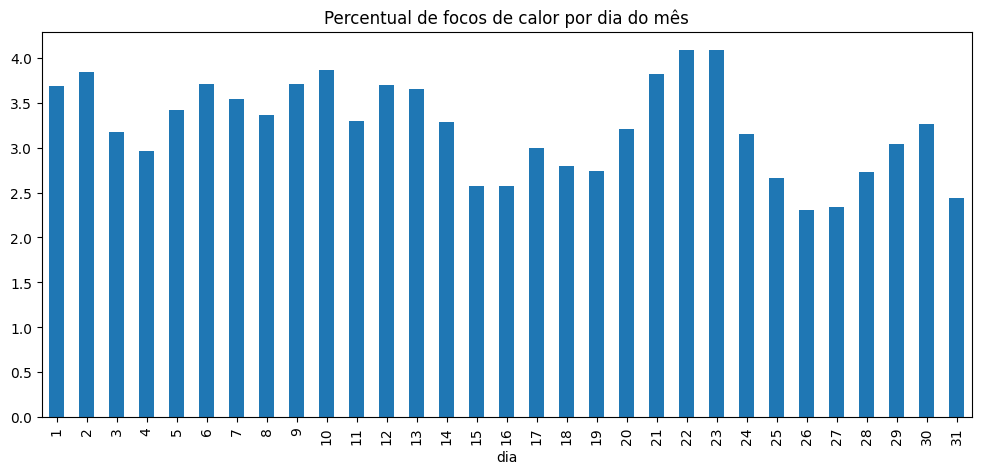

In [217]:
frequencia_dia.plot(kind="bar", figsize=(12,5), title="Percentual de focos de calor por dia do mês")

In [218]:
colunas_outliers = ["frp", "bright_ti4", "bright_ti5"]

for coluna in colunas_outliers:
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    outliers = (df[coluna] > limite_superior) | (df[coluna] < limite_inferior)
     
    print(f"Coluna: {coluna}")
    print(f"Limite inferior: {limite_inferior:.2f}")
    print(f"Limite superior: {limite_superior:.2f}")
    print(f"Quantidade de outliers: {outliers.sum()}")
    print("\n")

Coluna: frp
Limite inferior: -11.49
Limite superior: 25.39
Quantidade de outliers: 204702


Coluna: bright_ti4
Limite inferior: 270.02
Limite superior: 391.86
Quantidade de outliers: 1852


Coluna: bright_ti5
Limite inferior: 274.27
Limite superior: 323.51
Quantidade de outliers: 46613




In [219]:
base_corte = pd.Series(True, index=df.index)

for coluna in colunas_outliers:
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    
    iqr = q3 - q1
    
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    outliers = (df[coluna] > limite_superior) | (df[coluna] < limite_inferior) 

    base_corte = base_corte & ~outliers
df = df[base_corte].copy()

com_outliers = len(df_original)
sem_outliers = len(df)
diferenca_outliers = com_outliers - sem_outliers

print(f"DF com outliers {com_outliers}")
print("\n")
print(f"DF sem outliers {sem_outliers}")
print("\n")
print(f"Dados removidos {diferenca_outliers}")

DF com outliers 1935740


DF sem outliers 1713116


Dados removidos 222624


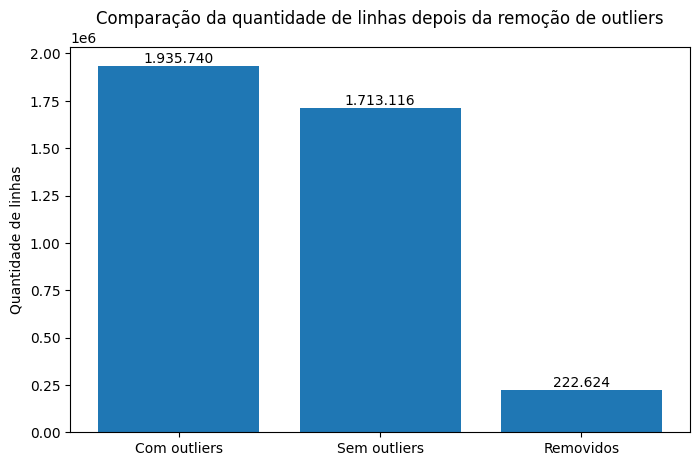

In [220]:
categorias = ["Com outliers", "Sem outliers", "Removidos"]
valores = [com_outliers, sem_outliers, diferenca_outliers]

plt.figure(figsize=(8, 5))

plt.bar(categorias, valores)

plt.title("Comparação da quantidade de linhas depois da remoção de outliers")
plt.ylabel("Quantidade de linhas")

for i, valor in enumerate(valores):
    plt.text(i, valor, f"{valor:,}".replace(",", "."), ha="center", va="bottom")

plt.show()

In [221]:
base_analise = df.copy()

colunas_numericas = [
    "frp",
    "bright_ti4",
    "bright_ti5",
    "scan",
    "track"
]

numericas = pd.DataFrame({
    "media" : base_analise[colunas_numericas].mean(),
    "mediana" : base_analise[colunas_numericas].median(),
    "moda" : base_analise[colunas_numericas].mode().iloc[0],
    "amplitude" : base_analise[colunas_numericas].max() - base_analise[colunas_numericas].min(),
    "desvio_padrao" : base_analise[colunas_numericas].std(),
    "coef_variacao_%" : (base_analise[colunas_numericas].std() / base_analise[colunas_numericas].mean()) * 100
})

numericas

,media,mediana,moda,amplitude,desvio_padrao,coef_variacao_%
frp,6.37,4.61,1.27,26.47,5.50,86.36
bright_ti4,331.31,334.35,367.00,73.56,17.78,5.37
bright_ti5,298.07,296.48,293.90,49.23,8.01,2.69
scan,0.46,0.43,0.39,0.48,0.09,18.73
track,0.48,0.44,0.36,0.42,0.11,23.88


#### Interpretando média, mediana, moda e variação

Olhando essa tabela com mais calma, eu percebi que algumas medidas ajudam a entender melhor os dados. No `frp`, por exemplo, a média ficou em `6.37`, mas a mediana ficou em `4.61` e a moda em `1.27`. Observando isso eu acabei percebendo que muitos focos de calor estão em valores mais baixos, só que alguns valores maiores acabam puxando a média para cima.

A moda em `1.27` deixa isso mais claro, porque ela mostra o valor que mais aparece. Então, mesmo tendo alguns focos mais intensos, a maior parte dos registros estão concentrados em intensidades menores.

Outra coisa que eu aprendi aqui foi que não dá para comparar o desvio padrão olhando só o número solto. De primeira, eu poderia achar que o `bright_ti4` varia mais, porque o desvio padrão dele é `17.78`, enquanto o do `frp` é `5.50`. Mas olhando melhor, o `bright_ti4` tem média `331.31`, então esse desvio não pesa tanto na escala dele. Já o `frp` tem média `6.37`, então um desvio de `5.50` pesa bem mais.

Foi por isso que o coeficiente de variação fez mais sentido para mim. Ele compara o desvio padrão com a média da própria coluna, então ajuda quando as variáveis estão em escalas diferentes. Nesse caso, o `frp` teve o maior coeficiente de variação, com `86.36%`, mostrando que ele é o mais instável proporcionalmente. Como o `frp` tem relação com a intensidade do fogo, isso indica que a intensidade muda bastante entre os focos registrados.

Já o `bright_ti4` e o `bright_ti5` têm valores bem maiores, mas isso não quer dizer que variam mais. O `bright_ti4` ficou com `5.37%` e o `bright_ti5` com `2.69%` no coeficiente de variação, então eles parecem mais estáveis dentro da própria escala.

Também achei importante lembrar que `scan` e `track` não mostram diretamente a intensidade do fogo. Eles têm médias baixas, `0.46` e `0.48`, porque são ligados à forma como o sensor fez a leitura. Mesmo assim, ajudam a entender melhor o registro feito pelo satélite.

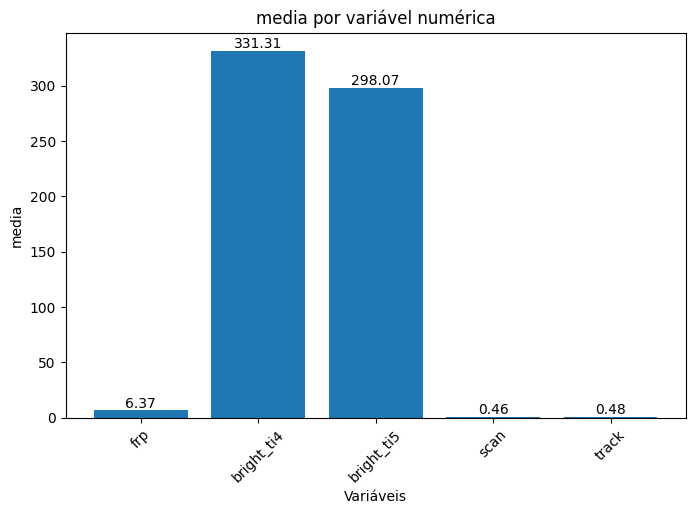

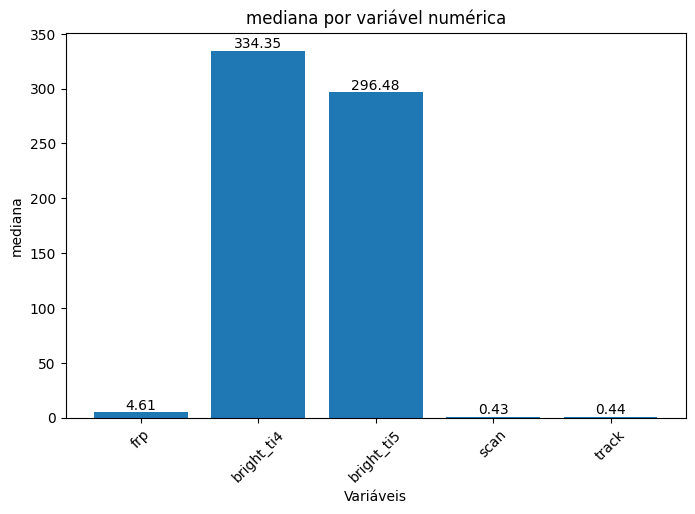

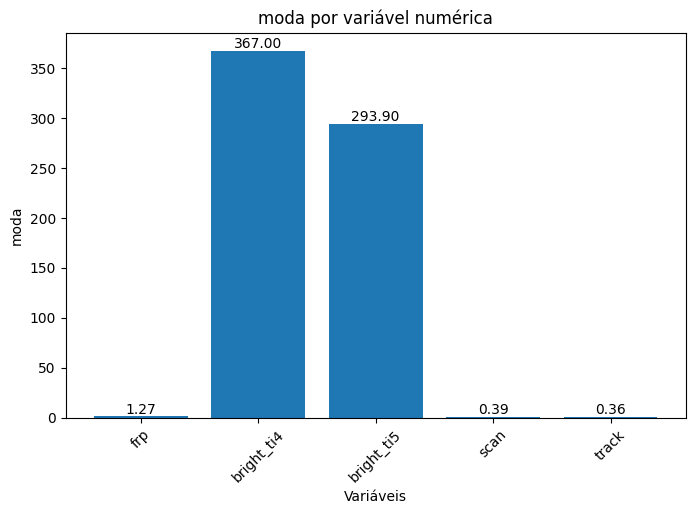

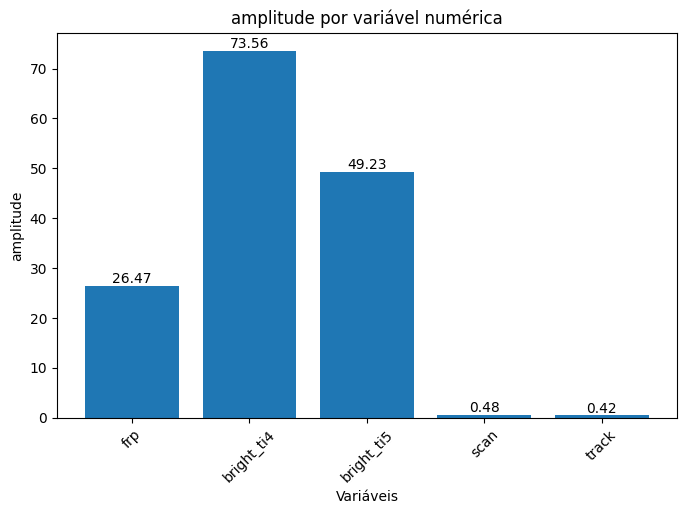

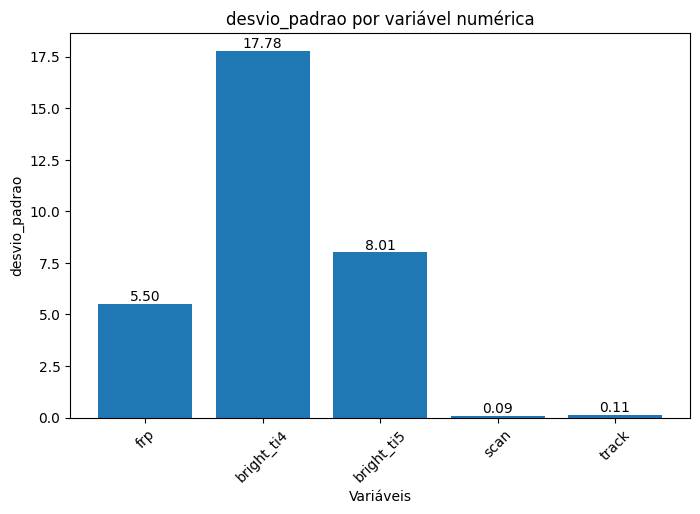

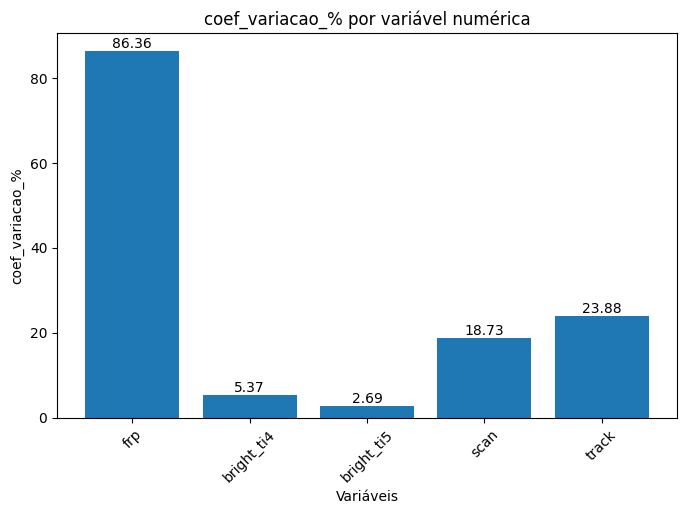

In [222]:
for metrica in numericas.columns:
    plt.figure(figsize=(8, 5))
    
    plt.bar(numericas.index, numericas[metrica])
    
    plt.title(f"{metrica} por variável numérica")
    plt.xlabel("Variáveis")
    plt.ylabel(metrica)
    
    plt.xticks(rotation=45)
    
    for i, valor in enumerate(numericas[metrica]):
        plt.text(i, valor, f"{valor:.2f}", ha="center", va="bottom")
    
    plt.show()

#### Comparando as métricas pelos gráficos

Nos gráficos, ficou mais fácil ver que cada coluna tem uma escala própria. Algumas barras ficam maiores não porque a variável é mais instável, mas porque os valores dela são maiores.

Por isso, o gráfico do coeficiente de variação foi o que mais me ajudou. Ele deixou mais claro que o `frp` chama mais atenção proporcionalmente, mesmo o `bright_ti4` tendo números maiores em outras métricas. Isso me ajudou a não confundir valor alto com variação alta.

In [223]:
quartis_percentis = (
    base_analise[colunas_numericas]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .rename(index = {
        0.25 : "q1",
        0.50 : "q2",
        0.75 : "q3",
        0.90 : "p90",
        0.95 : "p95",
        0.99 : "p99"
    })
)

quartis_percentis

,frp,bright_ti4,bright_ti5,scan,track
q1,2.15,313.84,292.49,0.39,0.38
q2,4.61,334.35,296.48,0.43,0.44
q3,8.78,343.71,303.85,0.50,0.56
p90,14.62,352.50,309.25,0.57,0.65
p95,18.66,367.00,312.26,0.62,0.71
p99,23.73,367.00,317.44,0.75,0.77


#### Interpretando os quartis e percentis

Nessa parte, os quartis me ajudaram a enxergar onde a maioria dos dados está concentrada. Para o `frp`, o Q1 ficou em `2.15`, o Q2 em `4.61` e o Q3 em `8.78`. Isso mostra que boa parte dos focos de calor tem intensidade mais baixa.

Depois, olhando os percentis maiores, aparece uma diferença gigante. O `frp` vai para `14.62` no P90, `18.66` no P95 e `23.73` no P99. Então parece que existe uma parte menor dos registros com intensidades bem mais altas, mesmo depois de retirar os outliers.

No `bright_ti4` e no `bright_ti5`, os valores também sobem dos quartis para os percentis, mas eles estão em outra escala. O `bright_ti4` vai de `313.84` no Q1 para `367.00` no P99, e o `bright_ti5` vai de `292.49` para `317.44`. Então, de novo, faz mais sentido olhar cada coluna dentro da própria escala.

Já `scan` e `track` continuam com valores baixos até nos percentis maiores, como `0.75` no P99 de `scan` e `0.77` no P99 de `track`. Provavelmente por serem colunas características da leitura do sensor, e não uma medida direta da força do fogo.

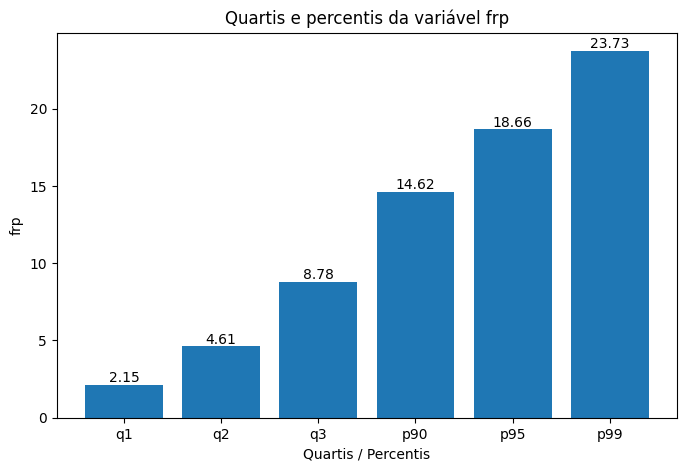

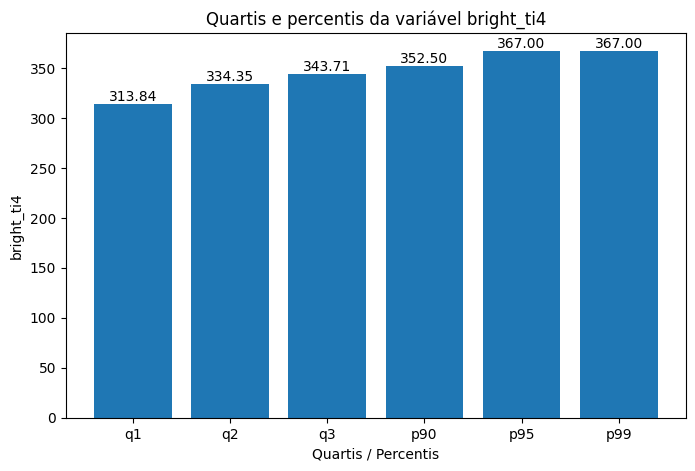

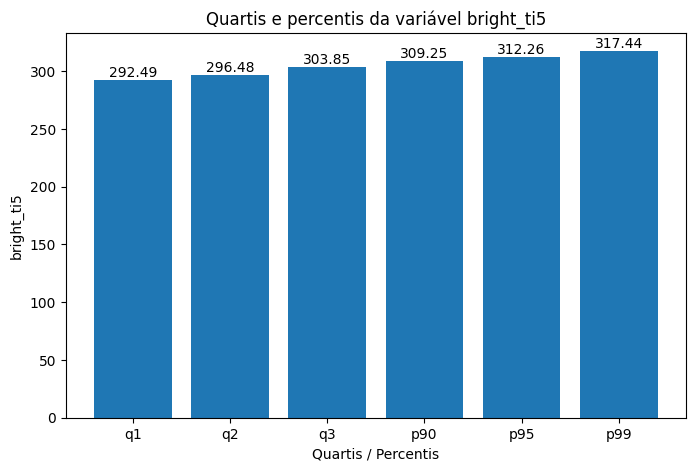

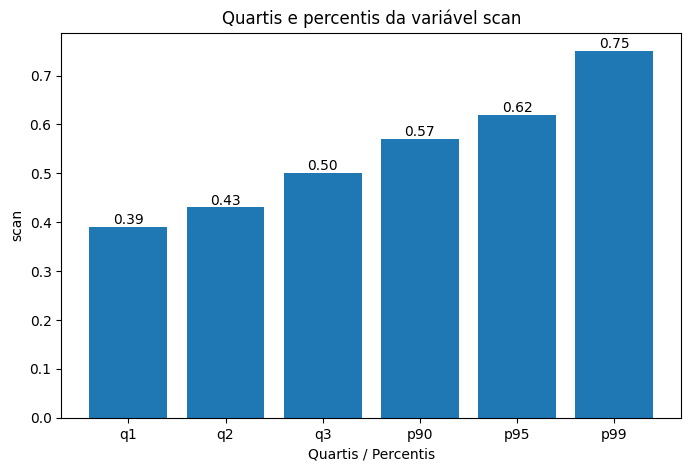

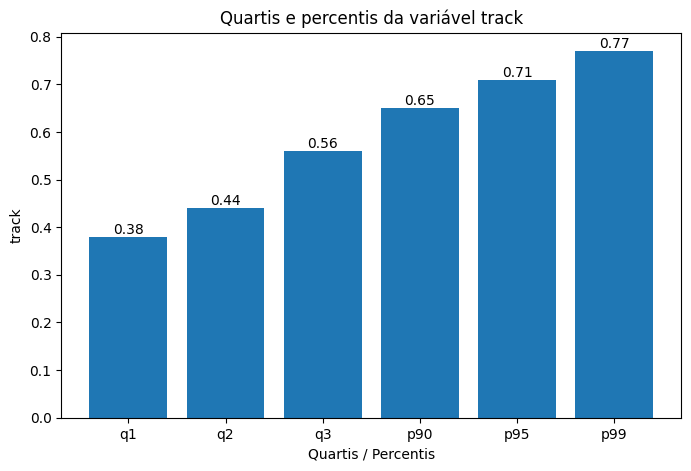

In [224]:
for coluna in quartis_percentis.columns:
    plt.figure(figsize=(8, 5))

    plt.bar(quartis_percentis.index, quartis_percentis[coluna])

    plt.title(f"Quartis e percentis da variável {coluna}")
    plt.xlabel("Quartis / Percentis")
    plt.ylabel(coluna)

    for i, valor in enumerate(quartis_percentis[coluna]):
        plt.text(i, valor, f"{valor:.2f}", ha="center", va="bottom")

    plt.show()

#### Olhando os percentis nos gráficos

Nos gráficos dos quartis e percentis, essa diferença ficou mais perceptivel. No `frp`, os primeiros valores ficam mais baixos, mas os últimos percentis sobem muito mais.

Esses gráficos também me ajudaram a ver que a média não mostra tudo. Os quartis e percentis deixam mais claro onde os dados realmente estão concentrados e onde começam a aparecer os valores mais altos.

## Perguntas de negócio

### 1. Quais variáveis apresentam maior variabilidade?

In [225]:
colunas_numericas_negocio = [
    "frp",
    "bright_ti4",
    "bright_ti5",
    "scan",
    "track"
]

variabilidade = pd.DataFrame({
    "media": df[colunas_numericas_negocio].mean(),
    "desvio_padrao": df[colunas_numericas_negocio].std(),
    "coef_variacao_%": (df[colunas_numericas_negocio].std() / df[colunas_numericas_negocio].mean()) * 100
}).sort_values("coef_variacao_%", ascending=False)

variabilidade.round(2)

,media,desvio_padrao,coef_variacao_%
frp,6.37,5.50,86.36
track,0.48,0.11,23.88
scan,0.46,0.09,18.73
bright_ti4,331.31,17.78,5.37
bright_ti5,298.07,8.01,2.69


Analisando a tabela, e os dados anteriores, eu percebi que o `frp` foi a variável que mais variou proporcionalmente, com 86.36% no coeficiente de variação.

Isso até faz sentido porque o `frp` representa a intensidade dos focos de calor. Então alguns focos podem ser bem fracos e outros bem mais fortes.

O coeficiente de variação ajudou porque compara o desvio padrão com a média da própria coluna. Assim fica mais justo comparar colunas com pesos diferentes.

Depois do `frp`, apareceram `track` com 23.88% e `scan` com 18.73%. Já `bright_ti4` e `bright_ti5` variaram menos proporcionalmente.

### 2. Existem padrões temporais relevantes?

In [226]:
frequencia_mes_negocio = pd.DataFrame({
    "quantidade": df["mes"].value_counts().sort_index(),
    "percentual": df["mes"].value_counts(normalize=True).sort_index() * 100
})

frequencia_mes_negocio.round(2)

,quantidade,percentual
mes,,
1,29952,1.75
2,32436,1.89
3,31833,1.86
4,12279,0.72
5,33801,1.97
6,69623,4.06
7,72766,4.25
8,464747,27.13
9,578021,33.74


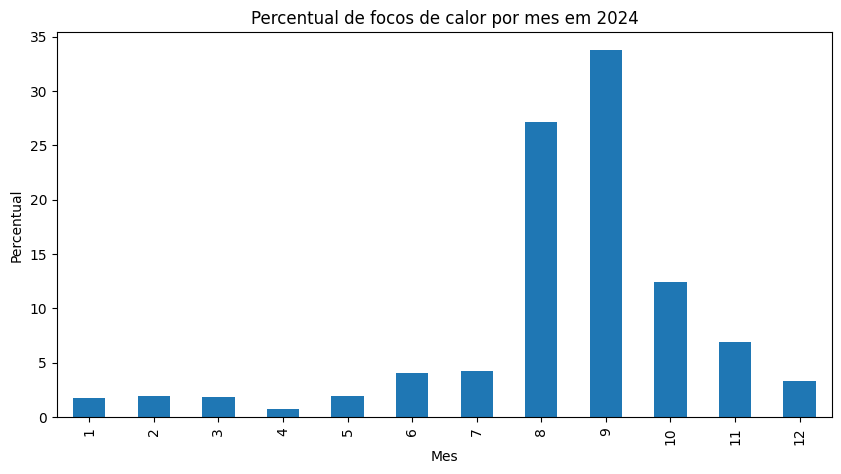

In [227]:
frequencia_mes_negocio["percentual"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Percentual de focos de calor por mes em 2024"
)

plt.xlabel("Mes")
plt.ylabel("Percentual")
plt.show()

Olhando os focos por mês, agosto e setembro foram os meses com maior numero de ocorrencias.

Setembro teve 578021 registros, que representam 33.74%, e agosto teve 464747 registros, com 27.13%.

Isso mostra que, em 2024, esses dois meses concentraram muitos focos de calor. Mas como a base tem só o ano de 2024, não dá para dizer que isso acontece todo ano. Só da para dizer apenas que foi um padrão dentro desse ano.

### 3. Há concentração geográfica de ocorrências?

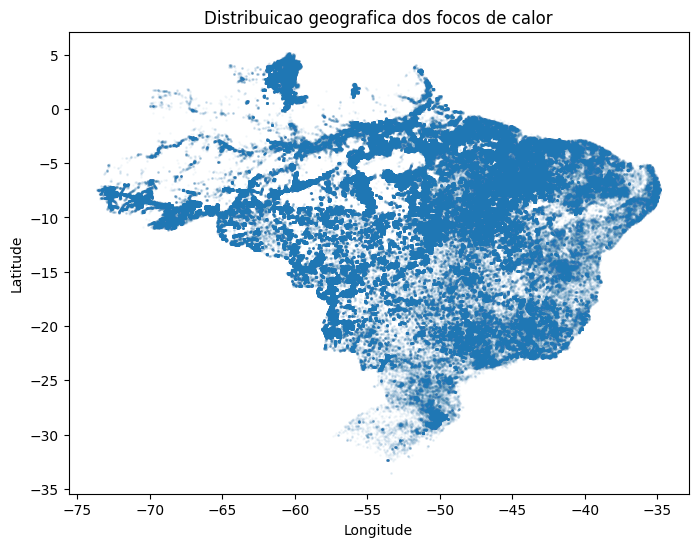

In [228]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["longitude"],
    df["latitude"],
    alpha=0.03,
    s=1
)

plt.title("Distribuicao geografica dos focos de calor")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Nesse gráfico, eu usei `longitude` e `latitude` para ver onde os focos aparecem no espaço.

Olhando os pontos, dá para perceber que esta bem espalhado, mas tem menos focos de calor nas regiões norte e sul

### 4. Existem valores extremos relevantes?

In [229]:
outliers_iqr_negocio = []

for coluna in ["frp", "bright_ti4", "bright_ti5"]:
    q1 = df_original[coluna].quantile(0.25)
    q3 = df_original[coluna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = (df_original[coluna] < limite_inferior) | (df_original[coluna] > limite_superior)

    outliers_iqr_negocio.append({
        "coluna": coluna,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "quantidade_outliers": outliers.sum()
    })

outliers_iqr_negocio = pd.DataFrame(outliers_iqr_negocio)
outliers_iqr_negocio.round(2)

,coluna,limite_inferior,limite_superior,quantidade_outliers
0,frp,-11.49,25.39,204702
1,bright_ti4,270.02,391.86,1852
2,bright_ti5,274.27,323.51,46613


In [230]:
frp_percentis_negocio = (
    df["frp"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .rename(index={
        0.25: "q1",
        0.50: "q2",
        0.75: "q3",
        0.90: "p90",
        0.95: "p95",
        0.99: "p99"
    })
)

frp_percentis_negocio.round(2)

q1     2.15
q2     4.61
q3     8.78
p90   14.62
p95   18.66
p99   23.73
Name: frp, dtype: float64

Na análise de outliers, o `frp` foi o que mais chamou atenção. Ele teve 204702 valores fora dos limites do IQR.

Isso foi bem mais do que `bright_ti4`, com 1852, e `bright_ti5`, com 46613.

Como o `frp` mede a intensidade do foco de calor, esses valores extremos representam focos muito mais fortes que a maioria.

Mesmo depois de remover os outliers, os percentis altos ainda mostram isso. O Q3 ficou em 8.78, mas o P90 foi para 14.62, o P95 para 18.66 e o P99 para 23.73. Então ainda existe uma parte menor dos focos com intensidade maior.

### 5. Há relação entre variáveis numéricas?

In [231]:
correlacao_numericas = df[
    ["frp", "bright_ti4", "bright_ti5", "scan", "track"]
].corr().round(2)

correlacao_numericas

,frp,bright_ti4,bright_ti5,scan,track
frp,1.00,0.69,0.47,0.17,0.15
bright_ti4,0.69,1.00,0.63,-0.01,0.10
bright_ti5,0.47,0.63,1.00,-0.11,-0.19
scan,0.17,-0.01,-0.11,1.00,0.50
track,0.15,0.10,-0.19,0.50,1.00


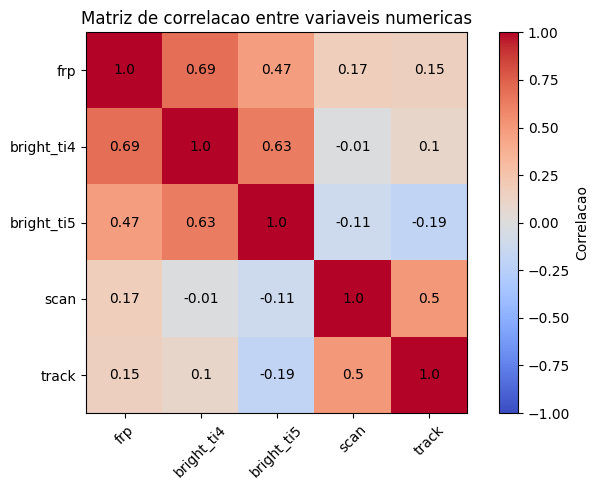

In [232]:
plt.figure(figsize=(7, 5))

plt.imshow(correlacao_numericas, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlacao")

plt.xticks(range(len(correlacao_numericas.columns)), correlacao_numericas.columns, rotation=45)
plt.yticks(range(len(correlacao_numericas.index)), correlacao_numericas.index)

for i in range(len(correlacao_numericas.index)):
    for j in range(len(correlacao_numericas.columns)):
        plt.text(j, i, correlacao_numericas.iloc[i, j], ha="center", va="center")

plt.title("Matriz de correlacao entre variaveis numericas")
plt.tight_layout()
plt.show()

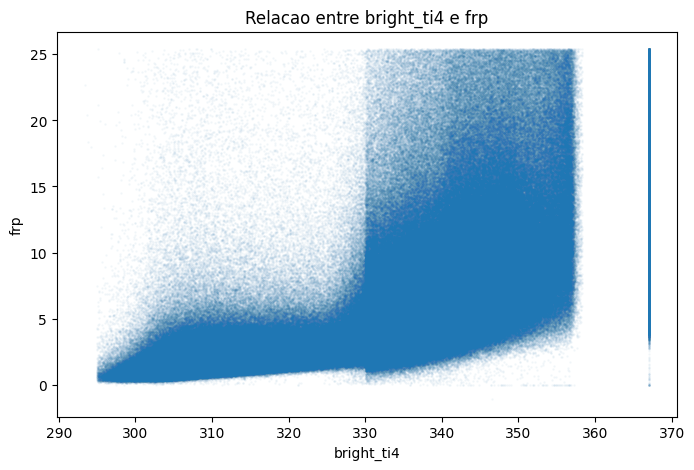

In [233]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["bright_ti4"],
    df["frp"],
    alpha=0.03,
    s=1
)

plt.title("Relacao entre bright_ti4 e frp")
plt.xlabel("bright_ti4")
plt.ylabel("frp")
plt.show()

Essa parte mostra se uma variável aumenta junto com outra.

Olhando a correlação, `bright_ti4` e `frp` tiveram valor positivo de 0.69. Isso indica que, quando o brilho ou temperatura em `bright_ti4` aumenta, o `frp` também tende a aumentar.

Também teve correlação positiva entre `bright_ti5` e `frp`, com 0.47, mas ela foi mais fraca.

Já `scan` e `track` tiveram valores menores com `frp`, então parecem ter uma relação mais fraca com a intensidade do foco.

### 6. Quais categorias concentram maior frequência?

In [234]:
frequencia_daynight = pd.DataFrame({
    "quantidade": df["daynight"].value_counts(),
    "percentual": df["daynight"].value_counts(normalize=True) * 100
})

frequencia_daynight.round(2)

,quantidade,percentual
daynight,,
D,972019,56.74
N,741097,43.26


In [235]:
frequencia_confidence = pd.DataFrame({
    "quantidade": df["confidence"].value_counts(),
    "percentual": df["confidence"].value_counts(normalize=True) * 100
})

frequencia_confidence.round(2)

,quantidade,percentual
confidence,,
n,1507844,88.02
l,118679,6.93
h,86593,5.05


In [236]:
frequencia_type = pd.DataFrame({
    "quantidade": df["type"].value_counts(),
    "percentual": df["type"].value_counts(normalize=True) * 100
})

frequencia_type.round(2)

,quantidade,percentual
type,,
0,1694124,98.89
2,14389,0.84
3,4603,0.27


In [237]:
frequencia_satellite_instrument = {
    "satellite": pd.DataFrame({
        "quantidade": df["satellite"].value_counts(),
        "percentual": df["satellite"].value_counts(normalize=True) * 100
    }).round(2),
    "instrument": pd.DataFrame({
        "quantidade": df["instrument"].value_counts(),
        "percentual": df["instrument"].value_counts(normalize=True) * 100
    }).round(2)
}

frequencia_satellite_instrument

{'satellite':            quantidade  percentual
 satellite                        
 N             1713116      100.00,
 'instrument':             quantidade  percentual
 instrument                        
 VIIRS          1713116      100.00}

Nas categorias, eu percebi que a maior parte dos registros aconteceu durante o dia.

Em `daynight`, a categoria D teve 972019 registros, ou 56.74%. A categoria N teve 741097, ou 43.26%.

Na coluna `confidence`, a categoria n apareceu muito mais, com 1507844 registros e 88.02%.

Na coluna `type`, a categoria 0 dominou a base, com 1694124 registros e 98.89%.

Também vi que `satellite` ficou todo como N e `instrument` todo como VIIRS. Então essas duas colunas não ajudam muito a comparar categorias diferentes nesse recorte.

### 7. Existem distribuições assimétricas?

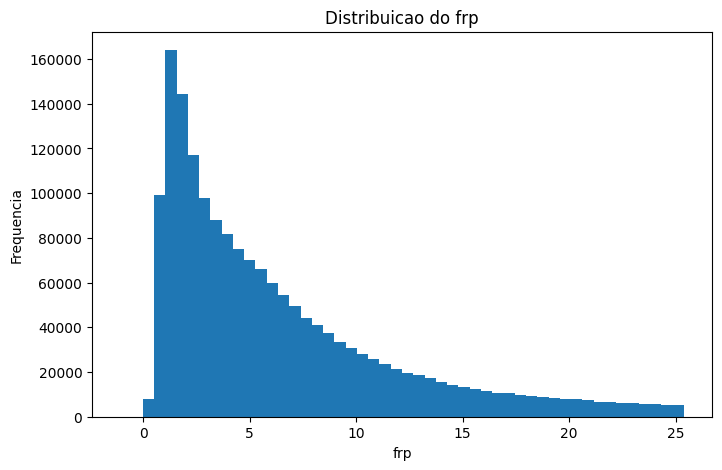

In [238]:
plt.figure(figsize=(8, 5))

plt.hist(df["frp"], bins=50)

plt.title("Distribuicao do frp")
plt.xlabel("frp")
plt.ylabel("Frequencia")
plt.show()

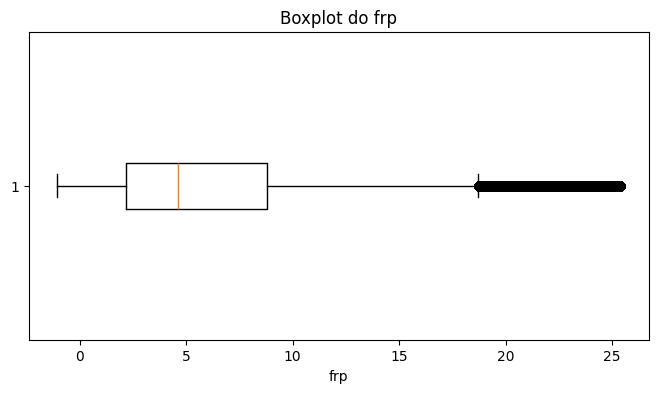

In [239]:
plt.figure(figsize=(8, 4))

plt.boxplot(df["frp"], vert=False)

plt.title("Boxplot do frp")
plt.xlabel("frp")
plt.show()

O histograma e o boxplot mostram que o `frp` não está distribuído de forma muito equilibrada.

A maior parte dos valores fica em intensidades menores, mas existe uma parte menor indo para valores mais altos.

Isso combina com o que apareceu antes: a média do `frp` ficou maior que a mediana, e os percentis mais altos também subiram bastante.

Isso me mostra que a maioria dos focos tem intensidade menor, mas ainda existe uma parte menor com intensidade mais alta, formando uma cauda na distribuição.

### Resumo

No geral, o `frp` foi uma das colunas mais importantes da análise. Ele teve a maior variação proporcional, muitos valores extremos e uma distribuição mais puxada para valores baixos, mas com focos mais fortes.

Também deu para ver que agosto e setembro concentraram muitos focos em 2024. Na parte geográfica, o gráfico mostrou áreas com mais pontos, mas sem dizer exatamente uma localização exata.

Nas categoricas, a maior parte apareceu durante o dia, com confiança n, tipo 0, satélite N e instrumento VIIRS.

# Criando modelo preditivo

In [256]:
base_modelo = df.sample(
    n = min(100_000, len(df)),
    random_state = 141106
).copy()

Como eu fiz a parte do modelo apenas como um extra, eu reduzi o escopo dos dados por conta do tempo do tempo de execução que estava levando 40 minutos para treinar o modelo

Para criar a variável que o modelo vai tentar prever, dividi a coluna `frp` em três categorias: baixa, média e alta intensidade. Usei os percentis da própria coluna para fazer essa separação.

In [257]:
q33 = base_modelo["frp"].quantile(0.33)
q66 = base_modelo["frp"].quantile(0.66)

def classificar_intensidade(valor):
    if valor <= q33:
        return "baixa"
    elif valor <= q66:
        return "media"
    else:
        return "alta"

base_modelo["intensidade"] = base_modelo["frp"].apply(classificar_intensidade)

base_modelo["intensidade"].value_counts(normalize=True) * 100

intensidade
alta    33.98
baixa   33.03
media   32.99
Name: proportion, dtype: float64

Separei as colunas numéricas e categóricas que vão entrar no modelo. Depois disso, defini o `x` com as variáveis de entrada e o `y` com a intensidade que o modelo vai tentar prever.

In [258]:
numericas_modelo = [
    "latitude",
    "longitude",
    "bright_ti4",
    "bright_ti5",
    "scan",
    "track",
    "mes",
    "dia",
    "hora"
]

categoricas_modelo = [
    "satellite",
    "instrument",
    "confidence",
    "daynight",
    "type"
]

x = base_modelo[numericas_modelo + categoricas_modelo]
y = base_modelo["intensidade"]

Como a base possui apenas dados de 2024, eu não consigo testar o modelo em outro ano, como 2025. Por isso, separei os próprios dados de 2024 em treino e teste.

A ideia é treinar o modelo com uma parte dos dados e testar em outra parte que ele ainda não viu.

In [259]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 141106,
    stratify = y
)

O modelo não entende dados em string, então, para isso, a gente transforma as colunas categóricas em binário usando `OneHotEncoder`. O Random Forest foi usado por conta da mistura de dados numéricos e categóricos.

In [260]:
preprocessador = ColumnTransformer(
    transformers = [
        ("categoricas", OneHotEncoder(handle_unknown =  "ignore"), categoricas_modelo)
    ],
    remainder = "passthrough"
)

modelo_rf = Pipeline(
    steps = [
        ("preprocessador", preprocessador),
        ("modelo", RandomForestClassifier(
            n_estimators = 50,
            max_depth = 10,
            random_state = 141106,
            n_jobs = -1,
            class_weight = "balanced"
        ))
    ]
)

modelo_rf.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['alta','baixa','media']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['latitude','longitude','bright_ti4',...,'confidence','daynight','type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

Usei o modelo para prever a intensidade dos registros de teste. depois eu comparei os dados previstos com os dados reais para descobrir a taxa de acerto do modelo, não foi taão bom mas como só tem os dados de 2024 não tem muito com oque trabalhar.


In [261]:
y_pred = modelo_rf.predict(x_test)

print(f"Taxa de acerto {accuracy_score(y_test, y_pred) * 100}%")
print("\n")
print(classification_report(y_test, y_pred))

Taxa de acerto 73.36%


              precision    recall  f1-score   support

        alta       0.77      0.72      0.74      6797
       baixa       0.83      0.86      0.85      6605
       media       0.60      0.63      0.61      6598

    accuracy                           0.73     20000
   macro avg       0.73      0.73      0.73     20000
weighted avg       0.73      0.73      0.73     20000



Aqui fiz uma tabela usando matriz de confusão para ter uma noção de onde o modelo acertou e errou. As linhas mostram o valor real e as colunas mostram o que foi previsto.


In [262]:
tabela_acertos = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["real_alta", "real_baixa", "real_media"],
    columns=["pred_alta", "pred_baixa", "pred_media"]
)

tabela_acertos

,pred_alta,pred_baixa,pred_media
real_alta,4871,121,1805
real_baixa,25,5675,905
real_media,1470,1002,4126


criei 2 colunas com os dados de teste com a intensidade real e a intensidade prevista pelo modelo.

In [263]:
df_previsoes = x_test.copy()
df_previsoes["intensidade_real"] = y_test.values
df_previsoes["intensidade_prevista"] = y_pred

df_previsoes.head()

,latitude,longitude,bright_ti4,bright_ti5,scan,track,mes,dia,hora,satellite,instrument,confidence,daynight,type,intensidade_real,intensidade_prevista
1027728,-2.23,-48.02,342.06,297.98,0.39,0.36,9,7,0,N,VIIRS,n,N,0,baixa,media
610516,-25.34,-49.15,341.91,301.58,0.46,0.39,8,22,0,N,VIIRS,n,D,0,media,alta
858292,-7.97,-43.95,342.67,306.22,0.39,0.59,9,1,0,N,VIIRS,n,D,0,media,media
786952,-23.80,-54.05,322.27,297.79,0.55,0.68,8,30,0,N,VIIRS,n,N,0,media,media
1176564,-13.02,-59.90,338.22,303.86,0.41,0.37,9,11,0,N,VIIRS,n,D,0,alta,media


Por fim plotei um grafico pra ter uma visualização mais facil


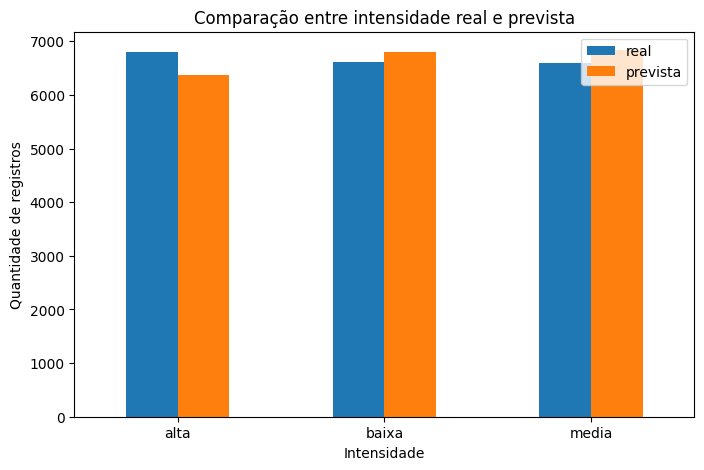

In [264]:
comparacao_previsao = pd.DataFrame({
    "real": df_previsoes["intensidade_real"].value_counts(),
    "prevista": df_previsoes["intensidade_prevista"].value_counts()
}).fillna(0)

comparacao_previsao.plot(
    kind="bar",
    figsize=(8, 5),
    title="Comparação entre intensidade real e prevista"
)

plt.xlabel("Intensidade")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=0)
plt.show()